# NicheFlow on ARTISTA Regeneration (train + 10.0 -> 15.0 inference)

This notebook uses NicheFlow core components to:
1. load ARTISTA data from h5ad,
2. map `obsm['X_spatial_input']` to spatial coordinates and `obsm['X_ae']` to features,
3. preprocess into NicheFlow dataset format,
4. train a PointCloudFlow model,
5. infer slice 15.0 from slice 10.0,
6. visualize coordinate and feature prediction quality.

In [1]:
# Optional: run once if dependencies are missing in current kernel.
# You can uncomment the pip lines if needed.
# %pip install anndata scanpy torch torch-geometric torchcfm torchdyn tqdm matplotlib
from __future__ import annotations

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

import importlib
import math
import sys
from pathlib import Path

repo_root = Path('/data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_codes/STFateFlow')
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from core.utils.inference import (
    bidirectional_nn_metrics,
    canonical_time_order,
    find_time_key,
    nn_of_x_in_y,
    wasserstein_distance,
)

required = [
    'anndata',
    'numpy',
    'torch',
    'matplotlib',
    'torch_geometric',
    'torchcfm',
    'torchdyn',
    # 'nicheflow',
]

missing = []
for pkg in required:
    try:
        importlib.import_module(pkg)
    except Exception:
        missing.append(pkg)


SEED = 2026
np.random.seed(SEED)
torch.manual_seed(SEED)

torch.set_float32_matmul_precision('high')

if not torch.cuda.is_available():
    raise RuntimeError('未检测到 CUDA GPU。请切换到可用 GPU 的环境后再训练。')

device = torch.device('cuda:1')
print('device =', device)
print('cuda name =', torch.cuda.get_device_name(0))


device = cuda:1
cuda name = NVIDIA A800 80GB PCIe


In [2]:
# -----------------------------
# User configurable parameters
# -----------------------------
h5ad_fp = Path('/data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_data/MOSTA/mosta_affine_subset_9_11.h5ad')
work_dir = Path('/data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_codes/STFateFlow/data/mosta')
work_dir.mkdir(parents=True, exist_ok=True)

coord_obsm_key = 'spatial'

print('h5ad path:', h5ad_fp)
print('output dir:', work_dir)


h5ad path: /data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_data/MOSTA/mosta_affine_subset_9_11.h5ad
output dir: /data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_codes/STFateFlow/data/mosta


In [3]:
adata = ad.read_h5ad(h5ad_fp)
print('adata shape:', adata.shape)
print('obsm keys:', list(adata.obsm.keys()))

import scanpy as sc

# sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=True, batch_key='Batch')

# Map user-provided spatial coordinates to the expected key.
# Gene features are read directly from adata.X by InfiniteGlobalRPCDataset.
adata.obsm['spatial'] = np.asarray(adata.obsm[coord_obsm_key], dtype=np.float32)

# adata = adata[adata.obs['time'] < 12.5]
# adata = adata[adata.obs['time'] >= 10.5]

timepoint_col = 'time'
cell_type_col = 'annotation'

if str(adata.obs[cell_type_col].dtype) != 'category':
    adata.obs[cell_type_col] = adata.obs[cell_type_col].astype('category')

timepoints_ordered = canonical_time_order(adata.obs[timepoint_col].dropna().unique())

print('timepoint column:', timepoint_col)
print('cell type column:', cell_type_col)
print('ordered timepoints:', timepoints_ordered)


adata shape: (53618, 2000)
obsm keys: ['X_ae', 'X_gene_input', 'X_pca', 'X_spatial_input', 'spatial']
timepoint column: time
cell type column: annotation
ordered timepoints: [np.float64(9.5), np.float64(10.5), np.float64(11.5)]


## Interpolation-CFM (real t0 source + velocity field supervision)

This section trains a new model with:
1. source state from real t0 data,
2. input as interpolation state between t0 and t1,
3. target as instantaneous velocity field from the interpolation path derivative.

In [4]:
import importlib

import torch

ds_mod = importlib.import_module("core.datasets.model_dataset")
stfateflow_collate = ds_mod.stfateflow_collate

stfateflowdataset = ds_mod.STFateFlowDataset

dataset_name = 'mosta'
fgw_alpha = 0.5
pi_cache_dir = Path('/data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_data/ot_pis')
pi_cache_path = pi_cache_dir / f'fgwot_pi_{dataset_name}_alpha{fgw_alpha}_9_11_gene_triu.npz'
size_per_slice = 4096
test_timepoint = -1.0

dataset = stfateflowdataset(
    adata=adata,
    timepoint_column=timepoint_col,
    cell_type_column=cell_type_col,
    timepoints_ordered=timepoints_ordered,
    seed=SEED,
    size_per_slice=size_per_slice,
    ot_plan_cache_path= pi_cache_path,
    ot_plan_normalize=True,
    test_timepoint=test_timepoint,
)

train_num_workers = 4
batch_size = 2
train_loader = DataLoader(
    dataset=dataset,
    batch_size=batch_size,
    num_workers=train_num_workers,
    pin_memory=True,
    persistent_workers=(train_num_workers > 0),
    collate_fn=stfateflow_collate,
)

In [13]:
import importlib

pc_vf_mod = importlib.import_module("core.models.backbones.pc_transformer")
flow_mod = importlib.import_module("core.models.STFateFlow")

# pc_vf_mod = importlib.reload(pc_vf_mod)
# flow_mod = importlib.reload(flow_mod)
# ds_mod = importlib.reload(ds_mod)

test_timepoint = -1.0

PointCloudTransformer = pc_vf_mod.PointCloudTransformer
stfateflow_model = flow_mod.STFateFlow_Module

num_steps_ode = 20
# Mixed precision on GPU: 'bf16' or 'fp16'
amp_dtype = 'bf16'

flow_ckpt_fp = work_dir / 'mosta_gene_interp_9_11_mse_cdm.pt'
lambda_features=0.1
lambda_pos=1.0
lambda_cdm=10.0

n_genes = adata.n_vars
n_slices = len(timepoints_ordered)

backbone = PointCloudTransformer(
    gene_dim=n_genes,
    coord_dim=2
)

stfateflow = stfateflow_model(
    lambda_features=lambda_features,
    lambda_pos=lambda_pos,
    lambda_cdm=lambda_cdm,
    backbone=backbone,
    num_steps=num_steps_ode,
    spatial_loss_type="mse"
).to(device)

# Training hyperparameters
lr = 3e-4
weight_decay = 1e-5
max_grad_norm = 1.0
optimizer = torch.optim.AdamW(stfateflow.parameters(), lr=lr, weight_decay=weight_decay)

autocast_dtype = torch.bfloat16 if amp_dtype == 'bf16' else torch.float16
use_scaler = amp_dtype == 'fp16'
scaler = torch.cuda.amp.GradScaler(enabled=use_scaler)
print('lr =', lr, 'max_grad_norm =', max_grad_norm, 'amp_dtype =', amp_dtype, 'use_scaler =', use_scaler)


lr = 0.0003 max_grad_norm = 1.0 amp_dtype = bf16 use_scaler = False


/data/yuz/tmp/ipykernel_2874375/1412337510.py:49: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_scaler)


Training STFateFlow (balanced):   0%|          | 0/4000 [00:00<?, ?it/s]

Saved STFateFlow checkpoint: /data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_codes/STFateFlow/data/mosta/mosta_gene_interp_9_11_mse_cdm.pt


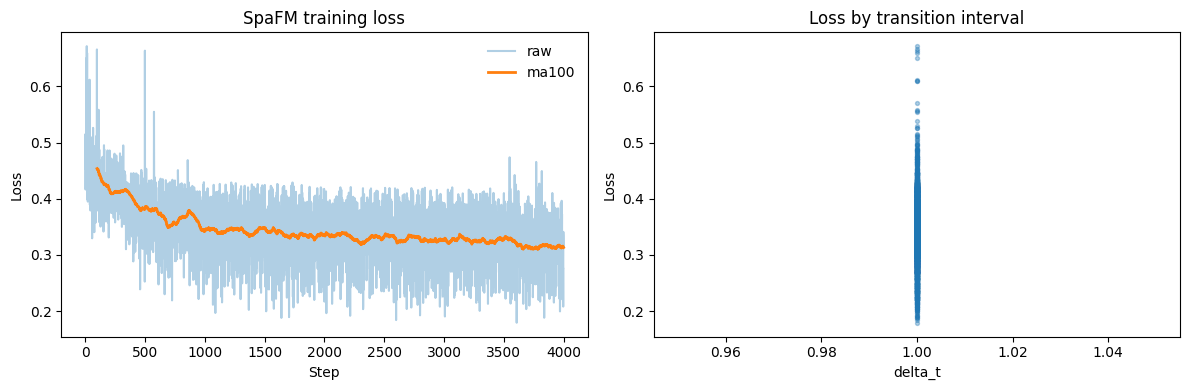

In [14]:
stfateflow.train()
stfateflow_iter = iter(train_loader)
stfateflow_loss_hist = []
stfateflow_diag_hist = []
train_steps = 1000
stfateflow_pbar = tqdm(range(train_steps), desc='Training STFateFlow (balanced)')
for step in stfateflow_pbar:

    batch = next(stfateflow_iter)
    batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}

    optimizer.zero_grad(set_to_none=True)
    with torch.autocast(device_type='cuda', dtype=autocast_dtype, enabled=True):
        losses = stfateflow.loss(batch)
        loss = losses['loss']

    if use_scaler:
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        grad_norm = torch.nn.utils.clip_grad_norm_(stfateflow.parameters(), max_grad_norm)
        scaler.step(optimizer)
        scaler.update()
    else:
        loss.backward()
        grad_norm = torch.nn.utils.clip_grad_norm_(stfateflow.parameters(), max_grad_norm)
        optimizer.step()

    stfateflow_loss_hist.append(float(loss.detach().cpu()))
    loss_dict = {
            'loss': float(loss.detach().cpu()),
            'loss_x': float(losses['loss_x'].detach().cpu()),
            'loss_pos': float(losses['loss_pos'].detach().cpu()),
            'weighted_loss_pos': float(losses['weighted_loss_pos'].detach().cpu()),
            'pred_vx_norm': float(losses['pred_vx_norm'].detach().cpu()),
            'pred_vpos_norm': float(losses['pred_vpos_norm'].detach().cpu()),
            'target_vx_norm': float(losses['target_vx_norm'].detach().cpu()),
            'target_vpos_norm': float(losses['target_vpos_norm'].detach().cpu()),
            'grad_norm': float(torch.as_tensor(grad_norm).detach().cpu()),
            'delta_t': float(batch['delta_t'].mean().detach().cpu()),
            't0_raw': tuple(float(v) for v in batch['t0_raw'].detach().cpu().tolist()),
            't1_raw': tuple(float(v) for v in batch['t1_raw'].detach().cpu().tolist()),
        }
    
    if lambda_cdm !=0:
        loss_dict['loss_cdm'] = float(losses['loss_cdm'].detach().cpu())
        loss_dict['weighted_loss_cdm'] = float(losses['weighted_loss_cdm'].detach().cpu())
            
    stfateflow_diag_hist.append(loss_dict)
    if (step + 1) % 50 == 0:
        postfix_dict = {
                'loss': f"{stfateflow_loss_hist[-1]:.4f}",
                'pred_pos_v': f"{stfateflow_diag_hist[-1]['pred_vpos_norm']:.4g}",
                'target_pos_v': f"{stfateflow_diag_hist[-1]['target_vpos_norm']:.4g}",
                'grad': f"{stfateflow_diag_hist[-1]['grad_norm']:.3g}",
            }
        
        if lambda_cdm !=0:
            postfix_dict['cdm'] = f"{stfateflow_diag_hist[-1]['loss_cdm']:.4g}"
            postfix_dict['w_cdm'] = f"{stfateflow_diag_hist[-1]['weighted_loss_cdm']:.4g}"
            
        stfateflow_pbar.set_postfix(
            postfix_dict
        )

torch.save(
    {
        'flow_state_dict': stfateflow.state_dict(),
        'n_genes': n_genes,
        'n_slices': n_slices,
        'timepoints_ordered': timepoints_ordered,
        'config': {
            'model': 'STFateFlow_khead_balanced',
            'size_per_slice': size_per_slice,
            'train_steps': train_steps,
            'lr': lr,
            'weight_decay': weight_decay,
            'max_grad_norm': max_grad_norm,
            'amp_dtype': amp_dtype,
            'num_steps_ode': num_steps_ode,
            'lambda_features': lambda_features,
            'lambda_pos': lambda_pos,
            'lambda_cdm': lambda_cdm,
            'spatial_loss_type': stfateflow.spatial_loss_type,
        },
    },
    flow_ckpt_fp,
)
print('Saved STFateFlow checkpoint:', flow_ckpt_fp)

loss_arr = np.asarray(stfateflow_loss_hist, dtype=np.float64)
window = min(100, max(1, len(loss_arr)))
ma = np.convolve(loss_arr, np.ones(window) / window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(loss_arr, alpha=0.35, label='raw')
axes[0].plot(np.arange(window - 1, window - 1 + len(ma)), ma, linewidth=2, label=f'ma{window}')
axes[0].set_title('STFateFlow training loss')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].legend(frameon=False)

diag_delta_t = np.asarray([d['delta_t'] for d in stfateflow_diag_hist], dtype=np.float64)
axes[1].scatter(diag_delta_t, loss_arr, s=8, alpha=0.35)
axes[1].set_title('Loss by transition interval')
axes[1].set_xlabel('delta_t')
axes[1].set_ylabel('Loss')
plt.tight_layout()
plt.show()


In [29]:
# Load a trained STFateFlow checkpoint. Run this cell after the setup/model-definition cell to skip retraining.
from core.models.checkpointing import load_stfateflow_checkpoint

flow_ckpt_fp = work_dir / 'mosta_gene_interp_9_11_l1_noncdm.pt'
# flow_ckpt_fp = work_dir / 'mosta_gene_interp_9_11.pt'

if not flow_ckpt_fp.exists():
    raise FileNotFoundError(f'STFateFlow checkpoint not found: {flow_ckpt_fp}. Run the training cell once first.')

stfateflow, stfateflow_load_info = load_stfateflow_checkpoint(
    flow_ckpt_fp,
    device=device,
    gene_dim=n_genes,
    coord_dim=2,
    num_steps=num_steps_ode,
    strict=False,
)
stfateflow.eval()

print(f'Loaded STFateFlow checkpoint: {flow_ckpt_fp}')
if stfateflow_load_info['missing_keys']:
    print('Missing keys:', stfateflow_load_info['missing_keys'])
if stfateflow_load_info['unexpected_keys']:
    print('Unexpected keys:', stfateflow_load_info['unexpected_keys'])


Loaded STFateFlow checkpoint: /data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_codes/STFateFlow/data/mosta/mosta_gene_interp_9_11_l1_noncdm.pt


In [34]:
ds_mod = importlib.reload(ds_mod)

stfateflow.eval()

size_per_slice = 4096

source_timepoint = 10.5
target_timepoint = 11.5
interpolation_timepoint = 11.5

t1_key = find_time_key(timepoints_ordered, source_timepoint)
t2_key = find_time_key(timepoints_ordered, target_timepoint)

source_pc = dataset.timepoint_pc[t1_key]
target_pc = dataset.timepoint_pc[t2_key]

X_t0 = source_pc.x.unsqueeze(0).to(device)
pos_t0 = source_pc.pos.unsqueeze(0).to(device)

n_cells = X_t0.size(1)
sample_t_start = float(source_pc.t_value.item())
sample_t_end = float(target_pc.t_value.item()) if interpolation_timepoint < 0 else float(interpolation_timepoint) - dataset.time_origin
print('sample_t_start =', sample_t_start, 'sample_t_end =', sample_t_end)

with torch.no_grad():
    sample_out = stfateflow.sample(
        X_t0=X_t0,
        pos_t0=pos_t0,
        t_start=sample_t_start,
        t_end=sample_t_end,
    )

    # Compatible with both return styles:
    # 1) tuple/list: (x_traj, pos_traj)
    # 2) dict: {'x_traj': ..., 'pos_traj': ...}
    if isinstance(sample_out, dict):
        x_traj = sample_out.get('x_traj', None)
        pos_traj = sample_out.get('pos_traj', None)
        potential_traj = sample_out.get('potential_traj', None)

    last_x = x_traj[-1] if isinstance(x_traj, (list, tuple)) else x_traj
    last_pos = pos_traj[-1] if isinstance(pos_traj, (list, tuple)) else pos_traj

    pred_x_interp = last_x.reshape(-1, n_genes).detach().cpu().numpy()
    coord_dim = int(pos_t0.shape[-1])
    pred_pos_interp = last_pos.reshape(-1, coord_dim).detach().cpu().numpy()

# Source potential/velocity visualization is in the next cell.


sample_t_start = 1.0 sample_t_end = 2.0


In [6]:
from core.models.cell_type_classifier import CellTypeClassifierInterface

ct_clf = CellTypeClassifierInterface(
    adata=adata,
    gene_key="X",
    coord_key=coord_obsm_key,
    label_key=cell_type_col,
    hidden_dim=256,
    depth=4,
    time_embed_dim=64,
    dropout=0.1,
    device="cuda:0",
)

save_path = work_dir / "MOSTA_cell_type_classifier.pt"
history = ct_clf.train(
    adata,
    gene_key="X",
    coord_key=coord_obsm_key,
    time_key="time",
    label_key=cell_type_col,
    epochs=500,
    batch_size=2048,
    lr=1e-3,
    class_weight=True,
    label_smoothing=0.05,
    save_path=save_path,
)

In [18]:
adata_subset = adata[adata.obs['time'] == 10.5]
pred_cell_type = ct_clf.predict(
    adata_subset,
    gene_key="X",
    coord_key=coord_obsm_key,
    time_key="time",
    return_cell_type=True,
    smooth_k=25,
)

In [ ]:
ckpt_path = work_dir / "MOSTA_cell_type_classifier.pt"
ct_clf = CellTypeClassifierInterface(
    ckpt_path=ckpt_path,
    device="cuda:0",
)

10.5

In [35]:
import anndata as ad
output_dir = '/data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_codes/STFateFlow/experiments/results/'
test_adata = adata[adata.obs['time'] == target_timepoint]
pred_adata = ad.AnnData(X=pred_x_interp)
pred_adata.obsm['pred_spatial'] = pred_pos_interp
# pred_adata.obsm['X_spatial_input'] = pred_pos_interp
pred_adata.obs['time'] = float(target_timepoint)

# pred_cell_type = ct_clf.predict(
#     pred_adata,
#     gene_key="X",
#     coord_key='pred_spatial',
#     time_key="time",
#     return_cell_type=True,
#     smooth_k=25,
# )

# pred_adata.obs['cell_type'] = pred_cell_type

In [36]:
interpolation_timepoint

11.5

In [37]:
output_file = f'MOSTA_stfateflow_inference_time_{int(interpolation_timepoint)}_l1_noncdm_abaltion.h5ad'
output_path = output_dir + output_file
pred_adata.write_h5ad(output_path)

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import to_hex

pred_spatial_key = "pred_spatial"
pred_color = "#898989"
annotation_key = "annotation"


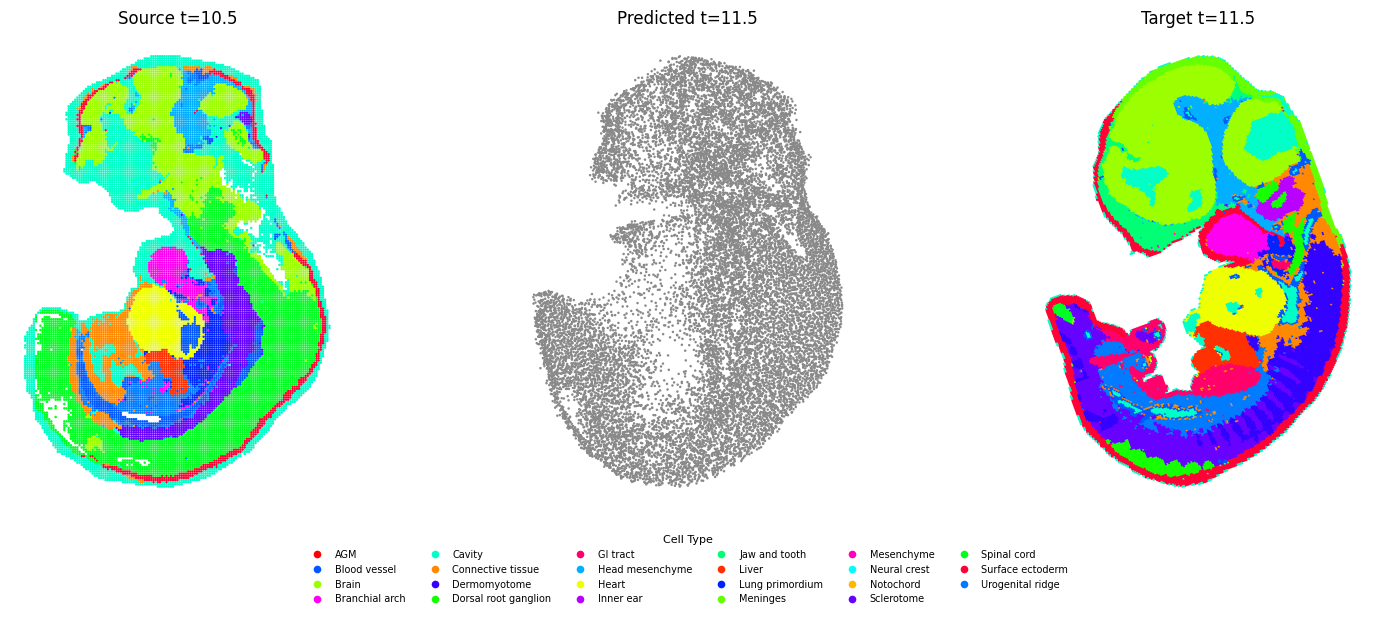

(<Figure size 1550x600 with 3 Axes>,
 array([<Axes: title={'center': 'Source t=10.5'}>,
        <Axes: title={'center': 'Predicted t=11.5'}>,
        <Axes: title={'center': 'Target t=11.5'}>], dtype=object))

In [38]:
def build_global_cell_type_palette(adata, annotation_key="annotation"):
    if str(adata.obs[annotation_key].dtype) == "category":
        cell_types = [str(x) for x in adata.obs[annotation_key].cat.categories]
    else:
        cell_types = sorted(adata.obs[annotation_key].astype(str).unique())

    hues = (np.arange(len(cell_types)) * 0.618033988749895) % 1.0
    colors = [to_hex(plt.cm.hsv(h)[:3]) for h in hues]
    return dict(zip(cell_types, colors))


def colors_from_cell_types(cell_types, palette):
    return np.asarray([palette[str(ct)] for ct in cell_types], dtype=object)


def cell_types_at_time(adata, time_value, time_key="time", annotation_key="annotation"):
    idx = np.asarray(np.where(adata.obs[time_key] == time_value)[0])
    return adata.obs.iloc[idx][annotation_key].astype(str).to_numpy()


def style_spatial_axis(ax, title):
    ax.set_facecolor("white")
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title, color="black", fontsize=12, pad=8)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    for spine in ax.spines.values():
        spine.set_visible(False)


def plot_prediction_with_true_annotations(
    adata,
    pred_adata,
    source_pos,
    target_pos,
    source_timepoint,
    target_timepoint,
    pred_pos=None,
    pred_spatial_key="pred_spatial",
    time_key="time",
    annotation_key="annotation",
    pred_color="#898989",
    point_size=3.2,
    save_path=None,
):
    palette = build_global_cell_type_palette(adata, annotation_key=annotation_key)
    all_cell_types = list(palette.keys())

    source_cell_types = cell_types_at_time(
        adata, source_timepoint, time_key=time_key, annotation_key=annotation_key
    )
    target_cell_types = cell_types_at_time(
        adata, target_timepoint, time_key=time_key, annotation_key=annotation_key
    )
    if pred_pos is None:
        pred_pos = np.asarray(pred_adata.obsm[pred_spatial_key])

    panels = [
        (source_pos, colors_from_cell_types(source_cell_types, palette), f"Source t={source_timepoint}"),
        (pred_pos, pred_color, f"Predicted t={target_timepoint}"),
        (target_pos, colors_from_cell_types(target_cell_types, palette), f"Target t={target_timepoint}"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15.5, 6.0), facecolor="white")
    for ax, (points, colors, title) in zip(axes, panels):
        ax.scatter(
            points[:, 0],
            points[:, 1],
            s=point_size,
            alpha=1.0,
            c=colors,
            marker="o",
            edgecolors="none",
            linewidths=0,
        )
        style_spatial_axis(ax, title)

    handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="",
            markersize=5.5,
            markerfacecolor=palette[ct],
            markeredgecolor="none",
            label=ct,
        )
        for ct in all_cell_types
    ]
    fig.legend(
        handles=handles,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.01),
        ncol=6,
        frameon=False,
        title="Cell Type",
        fontsize=7,
        title_fontsize=8,
        markerscale=1.0,
    )
    plt.tight_layout(rect=[0, 0.16, 1, 1], pad=0.2, w_pad=0.8)

    if save_path is not None:
        plt.savefig(save_path, dpi=600, bbox_inches="tight", facecolor="white")
    plt.show()
    return fig, axes


source_pos = dataset.timepoint_pc[t1_key].pos.detach().cpu().numpy()
target_pos = dataset.timepoint_pc[t2_key].pos.detach().cpu().numpy()
plot_prediction_with_true_annotations(
    adata=adata,
    pred_adata=pred_adata,
    source_pos=source_pos,
    target_pos=target_pos,
    source_timepoint=t1_key,
    target_timepoint=t2_key,
    pred_pos=pred_pos_interp,
    pred_spatial_key=pred_spatial_key,
    time_key=timepoint_col,
    annotation_key=annotation_key,
    pred_color=pred_color,
    save_path=work_dir / f"source_target_pred_gray_t{source_timepoint}_to_t{target_timepoint}.png",
)


In [ ]:
# The source/target/prediction visualization is now wrapped in
# plot_prediction_with_true_annotations above. Source and target use real
# cell-type annotations, while the prediction is shown in a single gray color.
